In [ ]:
!pip -q install -U scikit-learn pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 119.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 98.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.1 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, bu

Loaded:
  train: (82332, 45) | test: (175341, 45)
Features after alignment: 42
Categorical cols: ['proto', 'service', 'state']
Numeric cols: 39

=== Test Metrics (probability-based) ===
ROC AUC:  0.9746
AvgPrec:  0.9870
Brier:    0.0704 (lower is better)

=== Cost-Sensitive Operating Point ===
Costs used: C_FP=1.0, C_FN=5.0
Best threshold: 0.216
Min total cost: 20873.0

Confusion Matrix @ best threshold [ [TN FP], [FN TP] ]
[[ 44622  11378]
 [  1899 117442]]
TP=117442, TN=44622, FP=11378, FN=1899


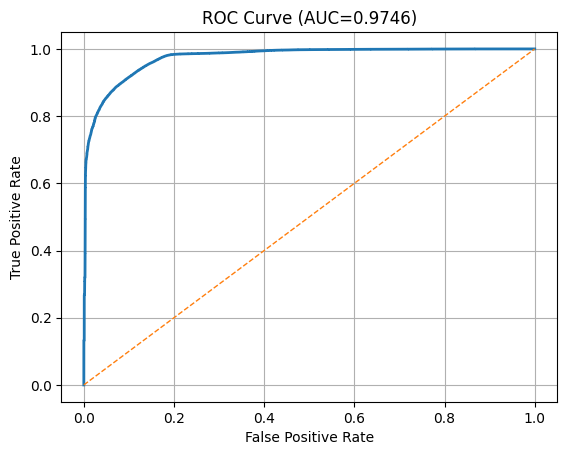

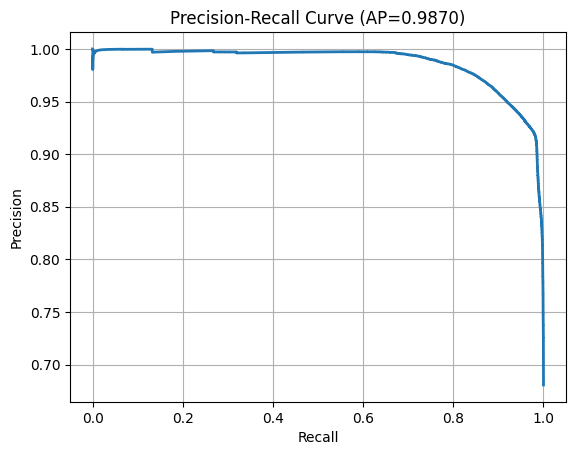

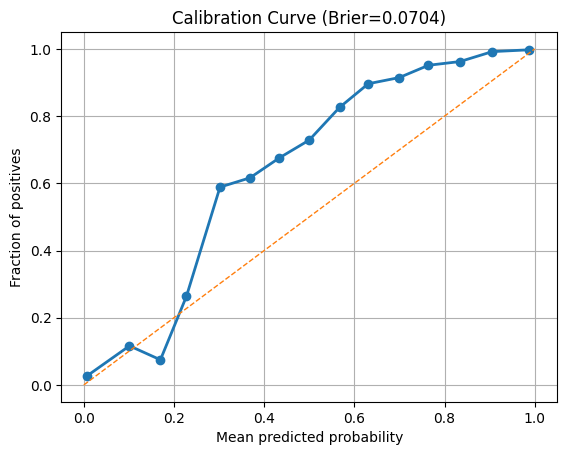

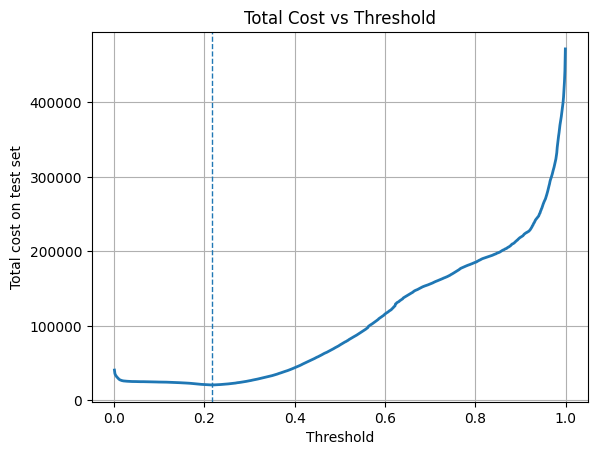

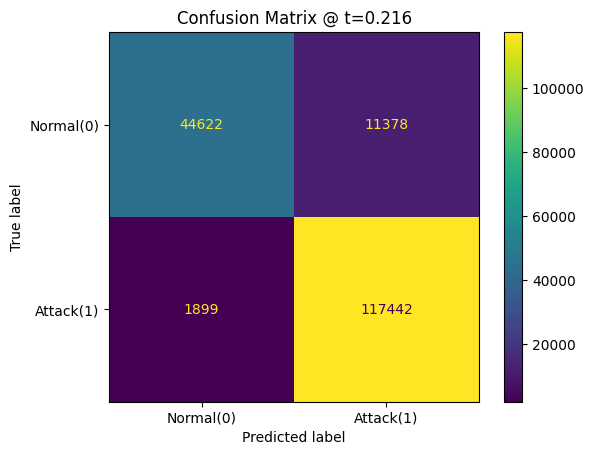


=== Top + Coefficients (push toward ATTACK) ===
service_dns                                8.0912
dttl                                       6.8525
ct_dst_sport_ltm                           5.4390
state_INT                                  5.3719
ct_srv_dst                                 4.2752
state_FIN                                  3.8602
ct_state_ttl                               3.7489
ct_srv_src                                 2.6873
proto_unas                                 1.9876
ct_src_dport_ltm                           1.8377
service_smtp                               1.6564
dloss                                      1.4958
dmean                                      1.4783
proto_sctp                                 1.4765
proto_ospf                                 1.3493

=== Top - Coefficients (push toward NORMAL) ===
ct_dst_src_ltm                            -11.6530
service_-                                 -4.6880
state_CON                                 -4.4394
s

In [ ]:

import os, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    brier_score_loss
)

warnings.filterwarnings("ignore")
TRAIN_PATH = "UNSW_NB15_training-set.csv"
TEST_PATH  = "UNSW_NB15_testing-set.csv"

for p in [TRAIN_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing file: {p}. Upload it to Colab first.")

df_train = pd.read_csv(TRAIN_PATH, low_memory=False)
df_test  = pd.read_csv(TEST_PATH,  low_memory=False)

print("Loaded:")
print("  train:", df_train.shape, "| test:", df_test.shape)
label_col = "label"
if label_col not in df_train.columns or label_col not in df_test.columns:
    raise ValueError("Expected a 'label' column in both train/test CSVs.")

y_train = df_train[label_col].astype(int).values
y_test  = df_test[label_col].astype(int).values
drop_cols = [
    "id", "srcip", "dstip", "sport", "dsport", "stime", "ltime",
    "label"
]

if "attack_cat" in df_train.columns:
    drop_cols.append("attack_cat")
if "attack_cat" in df_test.columns:
    drop_cols.append("attack_cat")

X_train = df_train.drop(columns=[c for c in drop_cols if c in df_train.columns], errors="ignore")
X_test  = df_test.drop(columns=[c for c in drop_cols if c in df_test.columns],  errors="ignore")
X_train, X_test = X_train.align(X_test, join="inner", axis=1)
print("Features after alignment:", X_train.shape[1])
cat_candidates = ["proto", "service", "state"]
cat_cols = [c for c in cat_candidates if c in X_train.columns]
num_cols = [c for c in X_train.columns if c not in cat_cols]

for c in num_cols:
    X_train[c] = pd.to_numeric(X_train[c], errors="coerce")
    X_test[c]  = pd.to_numeric(X_test[c], errors="coerce")

train_medians = X_train[num_cols].median(numeric_only=True)
X_train[num_cols] = X_train[num_cols].fillna(train_medians)
X_test[num_cols]  = X_test[num_cols].fillna(train_medians)

for c in cat_cols:
    X_train[c] = X_train[c].astype(str).fillna("missing")
    X_test[c]  = X_test[c].astype(str).fillna("missing")

print("Categorical cols:", cat_cols)
print("Numeric cols:", len(num_cols))
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", ohe, cat_cols),
    ],
    remainder="drop"
)

base_lr = LogisticRegression(
    solver="saga",
    penalty="l2",
    C=1.0,
    class_weight="balanced",
    max_iter=3000,
    n_jobs=-1,
    random_state=42
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", base_lr)
])

cal = CalibratedClassifierCV(estimator=model, method="sigmoid", cv=3)
cal.fit(X_train, y_train)
proba_test = cal.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, proba_test)
ap  = average_precision_score(y_test, proba_test)
brier = brier_score_loss(y_test, proba_test)

print("Test Metrics (probability-based)")
print(f"ROC AUC:  {auc:.4f}")
print(f"AvgPrec:  {ap:.4f}")
print(f"Brier:    {brier:.4f} (lower is better)")
C_FP = 1.0
C_FN = 5.0

thresholds = np.linspace(0.001, 0.999, 999)
y = y_test

costs = []
for t in thresholds:
    yhat = (proba_test >= t).astype(int)
    fp = np.sum((yhat == 1) & (y == 0))
    fn = np.sum((yhat == 0) & (y == 1))
    costs.append(C_FP * fp + C_FN * fn)

costs = np.array(costs)
best_idx = int(np.argmin(costs))
best_t = float(thresholds[best_idx])

print("\n=== Cost-Sensitive Operating Point ===")
print(f"Costs used: C_FP={C_FP}, C_FN={C_FN}")
print(f"Best threshold: {best_t:.3f}")
print(f"Min total cost: {costs[best_idx]:.1f}")

yhat_best = (proba_test >= best_t).astype(int)
cm = confusion_matrix(y, yhat_best, labels=[0,1])
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix @ best threshold [ [TN FP], [FN TP] ]")
print(cm)
print(f"TP={tp}, TN={tn}, FP={fp}, FN={fn}")
fpr, tpr, _ = roc_curve(y_test, proba_test)
plt.figure()
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0,1], [0,1], linestyle="--", linewidth=1)
plt.title(f"ROC Curve (AUC={auc:.4f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.show()

prec, rec, _ = precision_recall_curve(y_test, proba_test)
plt.figure()
plt.plot(rec, prec, linewidth=2)
plt.title(f"Precision-Recall Curve (AP={ap:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.show()

frac_pos, mean_pred = calibration_curve(y_test, proba_test, n_bins=15, strategy="uniform")
plt.figure()
plt.plot(mean_pred, frac_pos, marker="o", linewidth=2)
plt.plot([0,1], [0,1], linestyle="--", linewidth=1)
plt.title(f"Calibration Curve (Brier={brier:.4f})")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(thresholds, costs, linewidth=2)
plt.axvline(best_t, linestyle="--", linewidth=1)
plt.title("Total Cost vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Total cost on test set")
plt.grid(True)
plt.show()

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal(0)", "Attack(1)"])
disp.plot(values_format="d")
plt.title(f"Confusion Matrix @ t={best_t:.3f}")
plt.grid(False)
plt.show()
try:
    fitted_pipe = cal.calibrated_classifiers_[0].estimator
    pre = fitted_pipe.named_steps["preprocess"]
    lr  = fitted_pipe.named_steps["clf"]

    feature_names = []
    feature_names.extend(num_cols)

    if len(cat_cols) > 0:
        ohe = pre.named_transformers_["cat"]
        ohe_names = ohe.get_feature_names_out(cat_cols).tolist()
        feature_names.extend(ohe_names)

    coefs = lr.coef_.ravel()

    if len(coefs) == len(feature_names):
        top_k = 15
        idx_pos = np.argsort(coefs)[-top_k:][::-1]
        idx_neg = np.argsort(coefs)[:top_k]

        print("\n Top + Coefficients (push toward ATTACK) ")
        for i in idx_pos:
            print(f"{feature_names[i]:<40}  {coefs[i]: .4f}")

        print("\n Top - Coefficients (push toward NORMAL)")
        for i in idx_neg:
            print(f"{feature_names[i]:<40}  {coefs[i]: .4f}")
    else:
        print("\n(Interpretability) Coef/feature length mismatch; skipping coefficient table.")
except Exception as e:
    print("\n(Interpretability) Could not extract coefficients:", repr(e))

print("\nDone.")